# Install necessary packages

In [1]:
pip install numpy pandas lxml tensorflow torch gensim scikit-learn nltk

# Read Input Datasets

In [2]:
import xml.etree.ElementTree as ET
import pandas as pd

def parse_semeval_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    data = []
    
    for sentence in root.findall(".//sentence"):
        text = sentence.find("text").text
        aspect_terms = sentence.find("aspectTerms")
        if aspect_terms is not None:
            for aspect in aspect_terms.findall("aspectTerm"):
                term = aspect.get("term")
                polarity = aspect.get("polarity")
                if polarity != "conflict":  # Exclude 'conflict' for simplicity
                    data.append({"sentence": text, "aspect": term, "polarity": polarity})
    
    return pd.DataFrame(data)

# Example usage
file_path = "datasets/SemEval2014/Restaurants_Train.xml"  # Adjust path
df = parse_semeval_xml(file_path)
print(df.head())


                                            sentence   aspect  polarity
0               But the staff was so horrible to us.    staff  negative
1  To be completely fair, the only redeeming fact...     food  positive
2  The food is uniformly exceptional, with a very...     food  positive
3  The food is uniformly exceptional, with a very...  kitchen  positive
4  The food is uniformly exceptional, with a very...     menu   neutral


# Tokensie and filter unimportant words

In [3]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
df["tokens"] = df["sentence"].apply(word_tokenize)
print(df.head())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Prem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Prem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


                                            sentence   aspect  polarity  \
0               But the staff was so horrible to us.    staff  negative   
1  To be completely fair, the only redeeming fact...     food  positive   
2  The food is uniformly exceptional, with a very...     food  positive   
3  The food is uniformly exceptional, with a very...  kitchen  positive   
4  The food is uniformly exceptional, with a very...     menu   neutral   

                                              tokens  
0    [But, the, staff, was, so, horrible, to, us, .]  
1  [To, be, completely, fair, ,, the, only, redee...  
2  [The, food, is, uniformly, exceptional, ,, wit...  
3  [The, food, is, uniformly, exceptional, ,, wit...  
4  [The, food, is, uniformly, exceptional, ,, wit...  


# Label Encode for Class Category Varible

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["polarity"])
print(df.head())

                                            sentence   aspect  polarity  \
0               But the staff was so horrible to us.    staff  negative   
1  To be completely fair, the only redeeming fact...     food  positive   
2  The food is uniformly exceptional, with a very...     food  positive   
3  The food is uniformly exceptional, with a very...  kitchen  positive   
4  The food is uniformly exceptional, with a very...     menu   neutral   

                                              tokens  label  
0    [But, the, staff, was, so, horrible, to, us, .]      0  
1  [To, be, completely, fair, ,, the, only, redee...      2  
2  [The, food, is, uniformly, exceptional, ,, wit...      2  
3  [The, food, is, uniformly, exceptional, ,, wit...      2  
4  [The, food, is, uniformly, exceptional, ,, wit...      1  


# Graph for Train Calss Label Data Distribution

C:\Users\Prem\AppData\Local\Temp\ipykernel_21256\3755016967.py:6: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['polarity']).plot.bar(color = 'b')


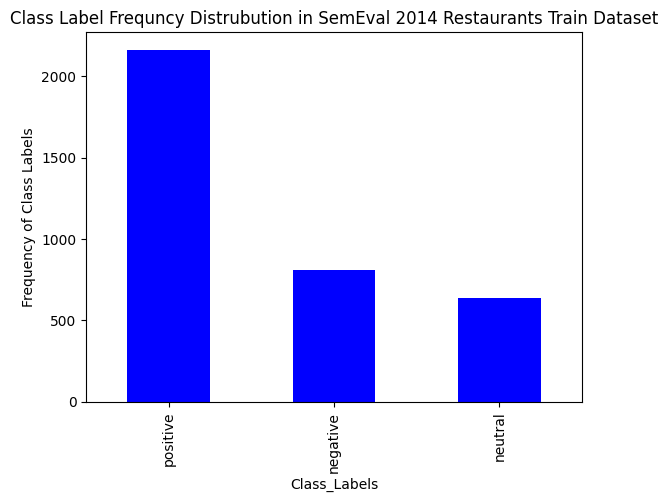

In [5]:
import matplotlib.pyplot as plt
import matplotlib
import pickle,datetime
from matplotlib import style

pd.value_counts(df['polarity']).plot.bar(color = 'b')
plt.xlabel('Class_Labels')
plt.ylabel('Frequency of Class Labels')
plt.title('Class Label Frequncy Distrubution in SemEval 2014 Restaurants Train Dataset')
plt.figsize=(20,20)  
plt.show()


# Bert Tokenizer for Dataset for Preprocessing

In [6]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

def get_bert_embeddings(sentence, aspect):
    inputs = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    embeddings = outputs.last_hidden_state  # [batch_size, seq_len, hidden_size]
    return embeddings

df["bert_embeddings"] = df.apply(lambda row: get_bert_embeddings(row["sentence"], row["aspect"]), axis=1)

# Aspect Embedding for the Train Dataset

In [7]:
def get_aspect_embedding(sentence, aspect, embeddings):
    tokens = tokenizer.tokenize(sentence)
    aspect_tokens = tokenizer.tokenize(aspect)
    start_idx = None
    for i in range(len(tokens) - len(aspect_tokens) + 1):
        if tokens[i:i+len(aspect_tokens)] == aspect_tokens:
            start_idx = i
            break
    if start_idx is not None:
        aspect_embedding = embeddings[0, start_idx:start_idx+len(aspect_tokens)].mean(dim=0)
        return aspect_embedding.numpy()
    return embeddings[0].mean(dim=0).numpy()  # Fallback: mean of all tokens

df["aspect_embedding"] = df.apply(lambda row: get_aspect_embedding(row["sentence"], row["aspect"], row["bert_embeddings"]), axis=1)

In [8]:
df.to_excel("output.xlsx", sheet_name='semeval2014')

In [9]:
df.head()

,sentence,aspect,polarity,tokens,label,bert_embeddings,aspect_embedding
0,But the staff was so horrible to us.,staff,negative,"[But, the, staff, was, so, horrible, to, us, .]",0,"[[[tensor(0.0851), tensor(0.4285), tensor(-0.2...","[-0.19922663, 0.25577906, -0.4822161, 0.034174..."
1,"To be completely fair, the only redeeming fact...",food,positive,"[To, be, completely, fair, ,, the, only, redee...",2,"[[[tensor(-0.1824), tensor(-0.1761), tensor(-0...","[-0.54952526, -0.4951653, -0.6391526, 0.360311..."
2,"The food is uniformly exceptional, with a very...",food,positive,"[The, food, is, uniformly, exceptional, ,, wit...",2,"[[[tensor(0.1410), tensor(0.1722), tensor(-0.1...","[-0.5015056, -0.2825815, -0.9114298, 0.1987781..."
3,"The food is uniformly exceptional, with a very...",kitchen,positive,"[The, food, is, uniformly, exceptional, ,, wit...",2,"[[[tensor(0.1410), tensor(0.1722), tensor(-0.1...","[-0.076005615, 0.063367076, 0.050718844, 0.259..."
4,"The food is uniformly exceptional, with a very...",menu,neutral,"[The, food, is, uniformly, exceptional, ,, wit...",1,"[[[tensor(0.1410), tensor(0.1722), tensor(-0.1...","[0.4959181, -0.68489534, -0.8030634, 0.0939103..."
